# 03 Classification

**Assignment 2: Explainable Maternal Health Risk Prediction** · KQC7016 Data Analytics

We train and compare **seven** classifiers for low/mid/high maternal risk, then go beyond a
single accuracy number with three analyses that the published work on this dataset omits:

| Block | What it adds |
|---|---|
| Model zoo (DT, RF, XGB, ExtraTrees, SVM, KNN, Naïve Bayes) | breadth — mirrors the 9-model comparison of Uddin & Karim (2025) |
| Resampling / feature-engineering ablation | tests SMOTE + derived vitals (MAP, pulse pressure) — documents that they do **not** beat the baseline |
| Binary *high-risk vs rest* reframing | the clinically-decisive task; honest and **much stronger** than 3-class |
| Duplicate-leakage sensitivity | reproduces the inflation that explains the literature's 0.89 numbers |

**Evaluation priority (clinically weighted):** Macro-F1 → high-risk recall → confusion
matrix; accuracy is reported but secondary (missing a high-risk patient is the costly error).

Everything is evaluated on the **deduplicated** split. The full (duplicate-containing) split
is used only at the end, to *quantify* leakage — not as a result we trust.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             recall_score, precision_score, accuracy_score,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", context="notebook")
PLOTS = Path("plots"); MODELS = Path("data/models"); MODELS.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
FEATURES = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]
CLASS_NAMES = ["low", "mid", "high"]   # encoded 0/1/2
HIGH = 2

def load_xy(split):
    tr = pd.read_csv(f"data/train{split}.csv"); te = pd.read_csv(f"data/test{split}.csv")
    return (tr[FEATURES], tr["risk_encoded"].astype(int),
            te[FEATURES], te["risk_encoded"].astype(int))

X_train, y_train, X_test, y_test = load_xy("")          # primary (deduplicated)
print("Primary  train:", X_train.shape, "test:", X_test.shape)
print("Train class counts:", dict(y_train.value_counts().sort_index()))

Primary  train: (360, 6) test: (91, 6)
Train class counts: {0: 186, 1: 85, 2: 89}


## 1. Model zoo

Seven classifiers spanning trees, boosting, margins, neighbours and probability:

| Model | Family | Imbalance handling | Scaling |
|---|---|---|---|
| Decision Tree | tree (interpretable baseline) | `class_weight="balanced"` | — |
| Random Forest | bagged trees (**primary**) | `class_weight="balanced"` | — |
| XGBoost | gradient boosting | balanced `sample_weight` | — |
| Extra Trees | randomised bagged trees | `class_weight="balanced"` | — |
| SVM (RBF) | max-margin | `class_weight="balanced"` | StandardScaler |
| KNN | instance-based | — (k-NN has no weighting) | StandardScaler |
| Naïve Bayes | probabilistic | — | StandardScaler |

Distance/margin models (SVM, KNN, NB) are wrapped in a `StandardScaler` pipeline so their
metrics are scaling-fair; tree models are scale-invariant.

In [2]:
def make_models():
    return {
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=5, class_weight="balanced",
            random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=400, max_depth=8, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.9,
            colsample_bytree=0.9, objective="multi:softprob", num_class=3,
            eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=400, max_depth=10, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "SVM": Pipeline([("sc", StandardScaler()),
                         ("clf", SVC(C=10, gamma="scale", class_weight="balanced",
                                     probability=True, random_state=RANDOM_STATE))]),
        "KNN": Pipeline([("sc", StandardScaler()),
                         ("clf", KNeighborsClassifier(n_neighbors=7))]),
        "Naive Bayes": Pipeline([("sc", StandardScaler()), ("clf", GaussianNB())]),
    }
models = make_models(); list(models)

['Decision Tree',
 'Random Forest',
 'XGBoost',
 'Extra Trees',
 'SVM',
 'KNN',
 'Naive Bayes']

## 2. Cross-validated Macro-F1 (training set)

5-fold stratified CV on the **training set only** gives a leakage-free estimate before we
touch the test set. With just 91 test rows (21 mid-risk), CV is the more stable signal — we
weight it heavily when reading the small held-out fluctuations.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, mdl in make_models().items():
    if name == "XGBoost":
        sw = compute_sample_weight("balanced", y_train)
        scores = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="f1_macro",
                                 params={"sample_weight": sw})
    else:
        scores = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="f1_macro")
    cv_rows.append({"model": name, "cv_macroF1_mean": scores.mean(), "cv_macroF1_std": scores.std()})
    print(f"{name:15s} macro-F1 = {scores.mean():.3f} +/- {scores.std():.3f}")
cv_df = pd.DataFrame(cv_rows)

Decision Tree   macro-F1 = 0.642 +/- 0.028


Random Forest   macro-F1 = 0.625 +/- 0.040


XGBoost         macro-F1 = 0.586 +/- 0.045


Extra Trees     macro-F1 = 0.642 +/- 0.057
SVM             macro-F1 = 0.599 +/- 0.044
KNN             macro-F1 = 0.598 +/- 0.051
Naive Bayes     macro-F1 = 0.537 +/- 0.030


## 3. Fit on full training set, evaluate on held-out test set

Refit each model on all 360 training rows; evaluate on the 91-row test set, recording
macro-F1, accuracy and **per-class recall** (watching the high-risk class).

In [4]:
def fit_eval(models, X_tr, y_tr, X_te, y_te, save=False):
    results, fitted, preds = [], {}, {}
    for name, mdl in models.items():
        if name == "XGBoost":
            mdl.fit(X_tr, y_tr, sample_weight=compute_sample_weight("balanced", y_tr))
        else:
            mdl.fit(X_tr, y_tr)
        yp = mdl.predict(X_te)
        rec = recall_score(y_te, yp, average=None, labels=[0, 1, 2])
        results.append({
            "model": name,
            "macroF1": f1_score(y_te, yp, average="macro"),
            "accuracy": accuracy_score(y_te, yp),
            "recall_low": rec[0], "recall_mid": rec[1], "recall_high": rec[2],
        })
        fitted[name] = mdl; preds[name] = yp
        if save:
            joblib.dump(mdl, MODELS / f"{name.lower().replace(' ', '_')}.joblib")
    return pd.DataFrame(results), fitted, preds

test_df, fitted, preds = fit_eval(make_models(), X_train, y_train, X_test, y_test, save=True)
test_df.round(3)

,model,macroF1,accuracy,recall_low,recall_mid,recall_high
0,Decision Tree,0.575,0.703,0.936,0.095,0.783
1,Random Forest,0.619,0.681,0.851,0.286,0.696
2,XGBoost,0.571,0.593,0.681,0.286,0.696
3,Extra Trees,0.594,0.648,0.787,0.286,0.696
4,SVM,0.565,0.626,0.787,0.238,0.652
5,KNN,0.559,0.637,0.851,0.190,0.609
6,Naive Bayes,0.477,0.637,1.000,0.048,0.435


In [5]:
# Detailed per-model classification reports
for name, yp in preds.items():
    print(f"\n===== {name} =====")
    print(classification_report(y_test, yp, target_names=CLASS_NAMES, digits=3))


===== Decision Tree =====
              precision    recall  f1-score   support

         low      0.688     0.936     0.793        47
         mid      0.667     0.095     0.167        21
        high      0.750     0.783     0.766        23

    accuracy                          0.703        91
   macro avg      0.701     0.605     0.575        91
weighted avg      0.698     0.703     0.642        91


===== Random Forest =====
              precision    recall  f1-score   support

         low      0.702     0.851     0.769        47
         mid      0.429     0.286     0.343        21
        high      0.800     0.696     0.744        23

    accuracy                          0.681        91
   macro avg      0.643     0.611     0.619        91
weighted avg      0.664     0.681     0.665        91


===== XGBoost =====
              precision    recall  f1-score   support

         low      0.640     0.681     0.660        47
         mid      0.261     0.286     0.273        21


## 4. Confusion matrices (top-3 models by macro-F1)

Rows = true class, columns = predicted. The clinically critical cell is **true high-risk
predicted as low/mid** (bottom-left) — a missed escalation.

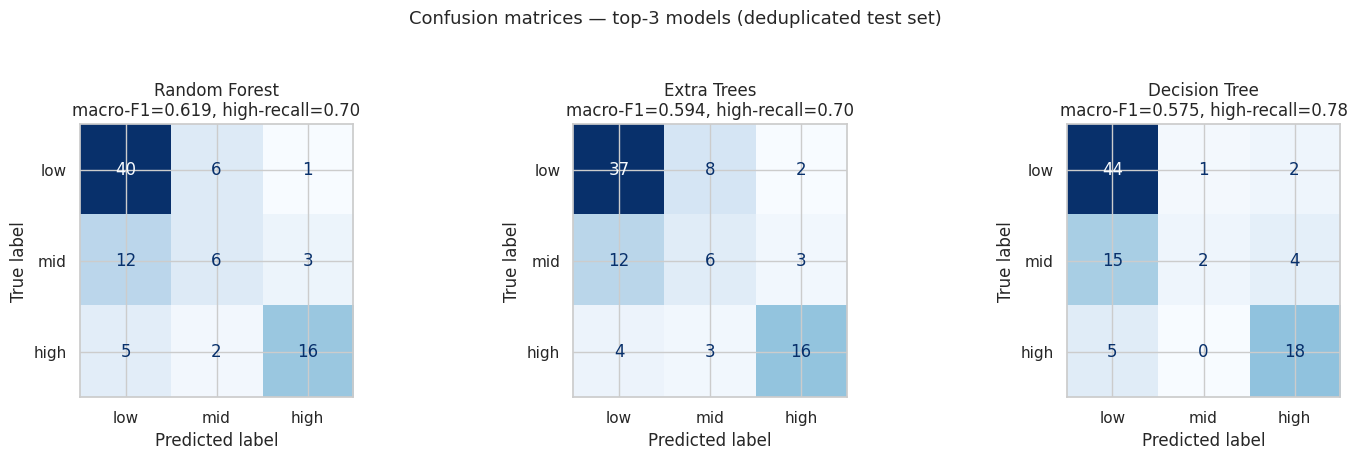

In [6]:
top3 = test_df.sort_values("macroF1", ascending=False)["model"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, preds[name], labels=[0, 1, 2])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    row = test_df.loc[test_df.model == name].iloc[0]
    ax.set_title(f"{name}\nmacro-F1={row.macroF1:.3f}, high-recall={row.recall_high:.2f}")
fig.suptitle("Confusion matrices — top-3 models (deduplicated test set)", y=1.04, fontsize=13)
plt.tight_layout(); plt.savefig(PLOTS / "08_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Model comparison

Combine cross-validated and held-out metrics. Decision criterion: macro-F1, with high-risk
recall as the clinical tie-breaker.

In [7]:
summary = cv_df.merge(test_df, on="model")
summary = summary[["model", "cv_macroF1_mean", "cv_macroF1_std", "macroF1", "accuracy",
                   "recall_high", "recall_mid", "recall_low"]].round(3)
summary = summary.sort_values("cv_macroF1_mean", ascending=False).reset_index(drop=True)
summary.to_csv("data/test_metrics.csv", index=False)
best = summary.sort_values(["macroF1", "recall_high"], ascending=False).iloc[0]
print("Best 3-class model:", best["model"], "| test macro-F1:", best["macroF1"],
      "| high-recall:", best["recall_high"])
summary

Best 3-class model: Random Forest | test macro-F1: 0.619 | high-recall: 0.696


,model,cv_macroF1_mean,cv_macroF1_std,macroF1,accuracy,recall_high,recall_mid,recall_low
0,Decision Tree,0.642,0.028,0.575,0.703,0.783,0.095,0.936
1,Extra Trees,0.642,0.057,0.594,0.648,0.696,0.286,0.787
2,Random Forest,0.625,0.040,0.619,0.681,0.696,0.286,0.851
3,SVM,0.599,0.044,0.565,0.626,0.652,0.238,0.787
4,KNN,0.598,0.051,0.559,0.637,0.609,0.190,0.851
5,XGBoost,0.586,0.045,0.571,0.593,0.696,0.286,0.681
6,Naive Bayes,0.537,0.030,0.477,0.637,0.435,0.048,1.000


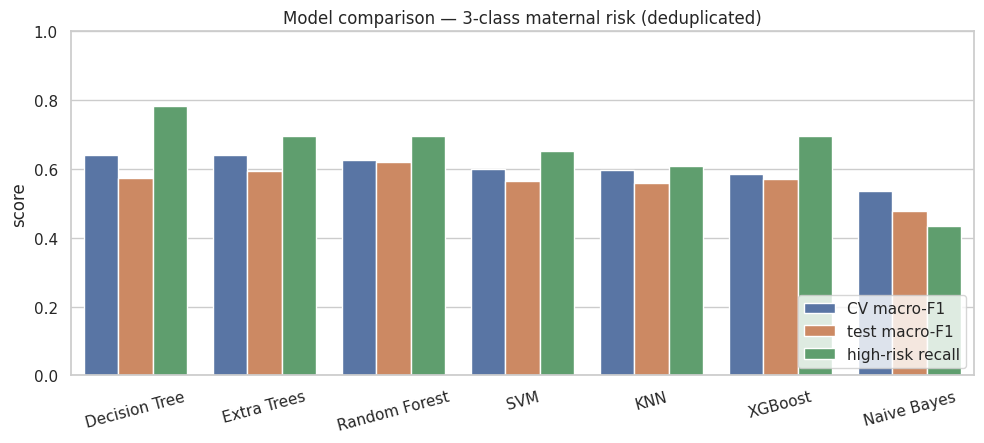

In [8]:
# Bar chart: CV macro-F1, test macro-F1 and high-risk recall per model
m = summary.melt(id_vars="model", value_vars=["cv_macroF1_mean", "macroF1", "recall_high"],
                 var_name="metric", value_name="score")
m["metric"] = m["metric"].map({"cv_macroF1_mean": "CV macro-F1",
                               "macroF1": "test macro-F1", "recall_high": "high-risk recall"})
plt.figure(figsize=(10, 4.6))
sns.barplot(data=m, x="model", y="score", hue="metric")
plt.ylim(0, 1); plt.title("Model comparison — 3-class maternal risk (deduplicated)")
plt.legend(title="", loc="lower right"); plt.xlabel(""); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(PLOTS / "09_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Hyperparameter Tuning — GridSearchCV (Random Forest)

Random Forest is the strongest 3-class model. We run an exhaustive `GridSearchCV` over five
key hyperparameters to find the optimal configuration and verify whether the 0.62 CV ceiling
is due to under-tuning or the dataset's conflicting-label noise.

| Hyperparameter | Search range | Effect |
|---|---|---|
| `n_estimators` | 200, 400, 600 | More trees → lower variance |
| `max_depth` | 5, 8, 10, `None` | Tree depth → controls overfitting |
| `min_samples_split` | 2, 5, 10 | Min samples required to split a node |
| `min_samples_leaf` | 1, 2, 4 | Min samples at leaf nodes |
| `max_features` | `"sqrt"`, `"log2"` | Features considered at each split |

Grid: **216 combinations × 5-fold CV = 1 080 fits**.  
Fixed: `class_weight="balanced"`, `random_state=42`. Scoring: macro-F1.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

rf_base_for_grid = RandomForestClassifier(
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
grid_search = GridSearchCV(
    estimator=rf_base_for_grid,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_search.fit(X_train, y_train)

print("Best parameters found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

baseline_cv  = cv_df.loc[cv_df.model == "Random Forest", "cv_macroF1_mean"].values[0]
baseline_row = summary.loc[summary.model == "Random Forest"].iloc[0]

print(f"\nCV macro-F1  — baseline: {baseline_cv:.3f}  tuned: {grid_search.best_score_:.3f}  "
      f"delta: {grid_search.best_score_ - baseline_cv:+.3f}")

# Evaluate tuned model on test set
rf_tuned  = grid_search.best_estimator_
yp_tuned  = rf_tuned.predict(X_test)
rec_tuned = recall_score(y_test, yp_tuned, average=None, labels=[0, 1, 2])

tuned_row = {
    "model":           "RF (tuned)",
    "cv_macroF1_mean": round(grid_search.best_score_, 3),
    "cv_macroF1_std":  round(grid_search.cv_results_["std_test_score"][grid_search.best_index_], 3),
    "macroF1":         round(f1_score(y_test, yp_tuned, average="macro"), 3),
    "accuracy":        round(accuracy_score(y_test, yp_tuned), 3),
    "recall_low":      round(rec_tuned[0], 3),
    "recall_mid":      round(rec_tuned[1], 3),
    "recall_high":     round(rec_tuned[2], 3),
}
base_row = {
    "model":           "RF (baseline)",
    "cv_macroF1_mean": round(float(baseline_row["cv_macroF1_mean"]), 3),
    "cv_macroF1_std":  round(float(baseline_row["cv_macroF1_std"]),  3),
    "macroF1":         round(float(baseline_row["macroF1"]),         3),
    "accuracy":        round(float(baseline_row["accuracy"]),        3),
    "recall_low":      round(float(baseline_row["recall_low"]),      3),
    "recall_mid":      round(float(baseline_row["recall_mid"]),      3),
    "recall_high":     round(float(baseline_row["recall_high"]),     3),
}
tuning_comparison = pd.DataFrame([base_row, tuned_row])[
    ["model", "cv_macroF1_mean", "cv_macroF1_std", "macroF1", "accuracy",
     "recall_low", "recall_mid", "recall_high"]
]

print("\nClassification report — RF tuned:")
print(classification_report(y_test, yp_tuned, target_names=CLASS_NAMES, digits=3))
print("Baseline vs Tuned:")
tuning_comparison

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best parameters found:
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 600

CV macro-F1  — baseline: 0.625  tuned: 0.664  delta: +0.039

Classification report — RF tuned:
              precision    recall  f1-score   support

         low      0.688     0.936     0.793        47
         mid      0.571     0.190     0.286        21
        high      0.800     0.696     0.744        23

    accuracy                          0.703        91
   macro avg      0.686     0.607     0.608        91
weighted avg      0.689     0.703     0.663        91

Baseline vs Tuned:


,model,cv_macroF1_mean,cv_macroF1_std,macroF1,accuracy,recall_low,recall_mid,recall_high
0,RF (baseline),0.625,0.040,0.619,0.681,0.851,0.286,0.696
1,RF (tuned),0.664,0.038,0.608,0.703,0.936,0.190,0.696


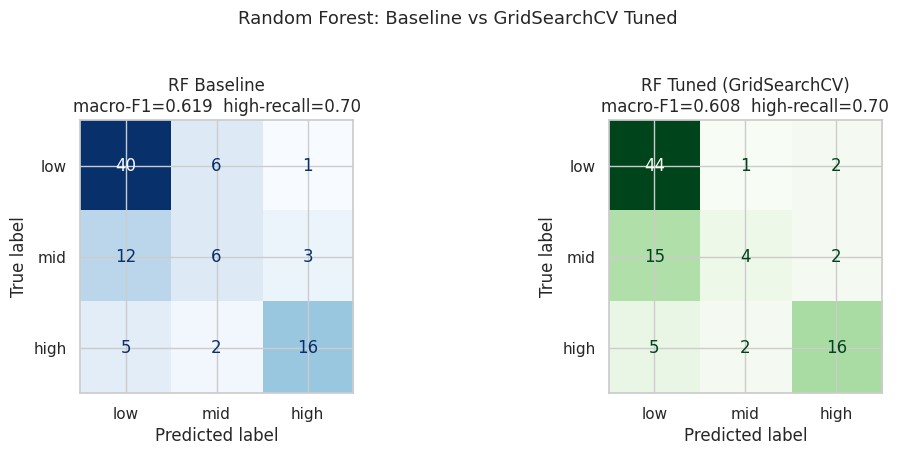

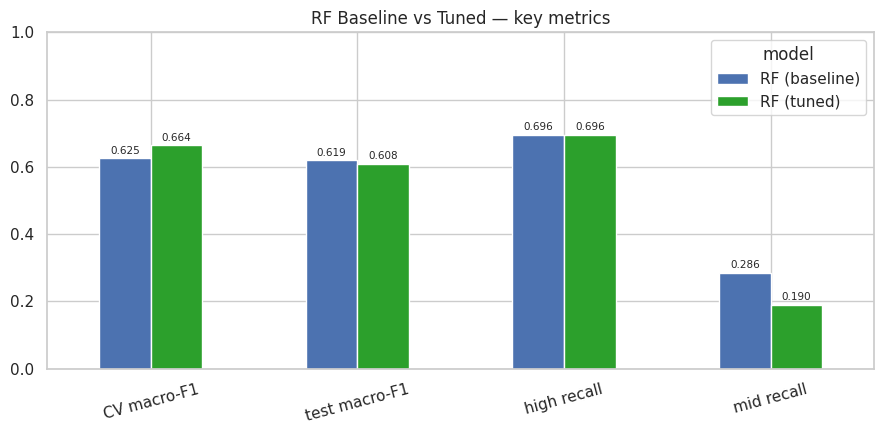

Tuned RF saved. Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 600}


In [10]:
# Confusion matrices: baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
cm_base  = confusion_matrix(y_test, preds["Random Forest"], labels=[0, 1, 2])
cm_tuned = confusion_matrix(y_test, yp_tuned,              labels=[0, 1, 2])
ConfusionMatrixDisplay(cm_base,  display_labels=CLASS_NAMES).plot(ax=axes[0], cmap="Blues",  colorbar=False)
axes[0].set_title(f"RF Baseline\nmacro-F1={base_row['macroF1']:.3f}  high-recall={base_row['recall_high']:.2f}")
ConfusionMatrixDisplay(cm_tuned, display_labels=CLASS_NAMES).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"RF Tuned (GridSearchCV)\nmacro-F1={tuned_row['macroF1']:.3f}  high-recall={tuned_row['recall_high']:.2f}")
plt.suptitle("Random Forest: Baseline vs GridSearchCV Tuned", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS / "10_rf_tuning_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

# Bar chart: key metrics before vs after
metrics_cols = ["cv_macroF1_mean", "macroF1", "recall_high", "recall_mid"]
labels_map   = {"cv_macroF1_mean": "CV macro-F1", "macroF1": "test macro-F1",
                "recall_high": "high recall",    "recall_mid": "mid recall"}
comp_plot = tuning_comparison.set_index("model")[metrics_cols].rename(columns=labels_map).T
ax = comp_plot.plot.bar(figsize=(9, 4.5), rot=15, color=["#4c72b0", "#2ca02c"])
ax.set_ylim(0, 1); ax.set_title("RF Baseline vs Tuned — key metrics")
ax.set_xlabel("")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", fontsize=7.5, padding=2)
plt.tight_layout()
plt.savefig(PLOTS / "11_rf_tuning_barplot.png", dpi=120, bbox_inches="tight")
plt.show()

# Save tuned model
joblib.dump(rf_tuned, MODELS / "random_forest_tuned.joblib")
print(f"Tuned RF saved. Best params: {grid_search.best_params_}")

## 7. Feature importance

Gini importance (Random Forest) vs gain importance (XGBoost). These preview the SHAP
analysis (notebook 05) and should agree that blood sugar and blood pressure dominate.

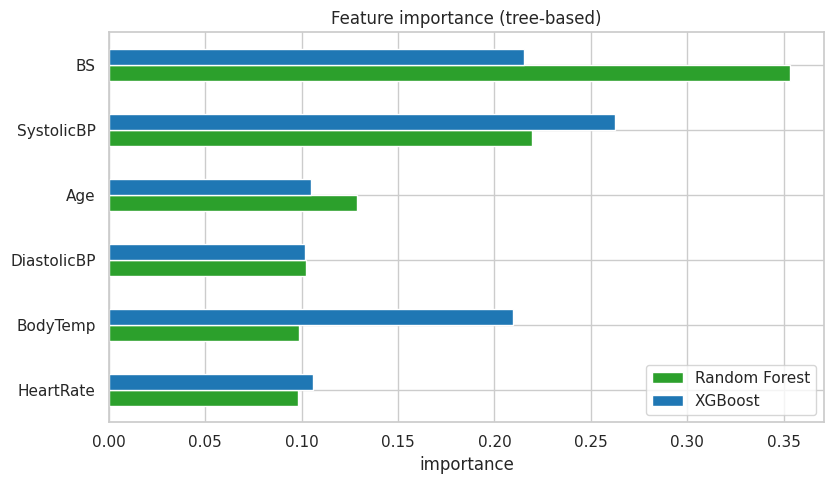

,Random Forest,XGBoost
BS,0.353,0.215
SystolicBP,0.219,0.263
Age,0.129,0.105
DiastolicBP,0.102,0.102
BodyTemp,0.099,0.210
HeartRate,0.098,0.106


In [11]:
imp = pd.DataFrame({
    "Random Forest": fitted["Random Forest"].feature_importances_,
    "XGBoost": fitted["XGBoost"].feature_importances_,
}, index=FEATURES).sort_values("Random Forest", ascending=True)
ax = imp.plot.barh(figsize=(8.5, 5), color=["#2ca02c", "#1f77b4"])
ax.set_title("Feature importance (tree-based)"); ax.set_xlabel("importance")
plt.tight_layout(); plt.savefig(PLOTS / "12_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
imp.sort_values("Random Forest", ascending=False).round(3)

## 8. Ablation — do SMOTE and engineered vitals help?

Two standard "fixes" for the weak mid-class are tested honestly:

- **Engineered vitals:** `MAP` (mean arterial pressure = DBP + (SBP−DBP)/3) and
  `PulsePressure` (SBP − DBP) — clinically meaningful blood-pressure summaries.
- **SMOTE:** synthetic oversampling of the minority classes, applied **inside** each CV fold
  (via an `imblearn` pipeline) so no synthetic row leaks into validation.

We compare them against the baseline Random Forest. The honest result (below) is that
**neither beats the baseline** — MAP/PP are linear combinations of SBP/DBP (redundant), and
SMOTE cannot invent separation that the conflicting-label noise has erased. This negative
result is evidence for the *ceiling*, not a modelling failure.

In [12]:
def engineer(df):
    d = df.copy()
    d["MAP"] = d["DiastolicBP"] + (d["SystolicBP"] - d["DiastolicBP"]) / 3
    d["PulsePressure"] = d["SystolicBP"] - d["DiastolicBP"]
    return d

ENG = FEATURES + ["MAP", "PulsePressure"]
Xtr_e, Xte_e = engineer(X_train), engineer(X_test)

def quick_eval(clf, Xtr, Xte):
    cvs = cross_val_score(clf, Xtr, y_train, cv=cv, scoring="f1_macro")
    clf.fit(Xtr, y_train); yp = clf.predict(Xte)
    rec = recall_score(y_test, yp, average=None, labels=[0, 1, 2])
    return {"cv_macroF1": cvs.mean(), "test_macroF1": f1_score(y_test, yp, average="macro"),
            "accuracy": accuracy_score(y_test, yp), "recall_mid": rec[1], "recall_high": rec[2]}

rf_kw = dict(n_estimators=400, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
abl = {
    "RF baseline (6 feats, class_weight)":
        quick_eval(RandomForestClassifier(class_weight="balanced", **rf_kw), X_train[FEATURES], X_test[FEATURES]),
    "RF + engineered vitals":
        quick_eval(RandomForestClassifier(class_weight="balanced", **rf_kw), Xtr_e[ENG], Xte_e[ENG]),
    "RF + SMOTE":
        quick_eval(ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                ("clf", RandomForestClassifier(**rf_kw))]), X_train[FEATURES], X_test[FEATURES]),
    "RF + SMOTE + engineered vitals":
        quick_eval(ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                                ("clf", RandomForestClassifier(**rf_kw))]), Xtr_e[ENG], Xte_e[ENG]),
}
ablation = pd.DataFrame(abl).T.round(3)
ablation.to_csv("data/resampling_ablation.csv")
print("Ablation — none beats the baseline (mid-recall stays ~0.3):")
ablation

Ablation — none beats the baseline (mid-recall stays ~0.3):


,cv_macroF1,test_macroF1,accuracy,recall_mid,recall_high
"RF baseline (6 feats, class_weight)",0.625,0.619,0.681,0.286,0.696
RF + engineered vitals,0.623,0.590,0.659,0.238,0.696
RF + SMOTE,0.641,0.556,0.648,0.143,0.696
RF + SMOTE + engineered vitals,0.626,0.605,0.659,0.286,0.696


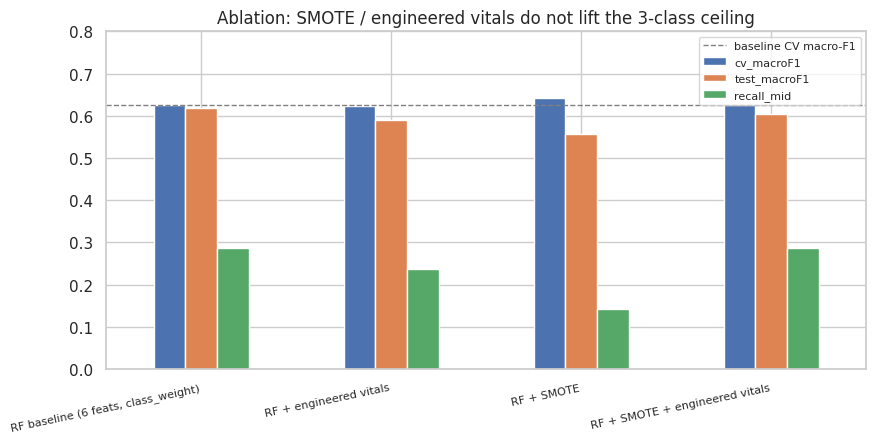

In [13]:
ax = ablation[["cv_macroF1", "test_macroF1", "recall_mid"]].plot.bar(figsize=(9, 4.6))
ax.set_ylim(0, 0.8); ax.set_title("Ablation: SMOTE / engineered vitals do not lift the 3-class ceiling")
ax.set_xlabel(""); ax.set_xticklabels(ablation.index, rotation=12, ha="right", fontsize=8)
ax.axhline(ablation.loc["RF baseline (6 feats, class_weight)", "cv_macroF1"],
           ls="--", c="gray", lw=1, label="baseline CV macro-F1")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "13_resampling_ablation.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Clinically-focused reframing — high-risk vs the rest

The 3-class macro-F1 is capped because *mid* overlaps *low* and *high* in vital-sign space
(see the density/boxplots in notebook 02). But the **decision that matters clinically** is
binary: *does this patient need escalation (high-risk) or not?* Collapsing low+mid into one
"not-high" class removes the ambiguous boundary and yields a much stronger, **honest** model
— accuracy near the literature's headline, but with **no duplicate leakage**.

In [14]:
yb_tr = (y_train == HIGH).astype(int)
yb_te = (y_test == HIGH).astype(int)

bin_models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", **rf_kw),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             eval_metric="logloss", scale_pos_weight=3,
                             random_state=RANDOM_STATE, n_jobs=-1),
}
bin_rows = {}
bin_preds = {}
for name, mdl in bin_models.items():
    cvf1 = cross_val_score(mdl, X_train, yb_tr, cv=cv, scoring="f1").mean()
    mdl.fit(X_train, yb_tr); yp = mdl.predict(X_test)
    bin_preds[name] = yp
    bin_rows[name] = {
        "cv_F1_high": cvf1,
        "test_F1_high": f1_score(yb_te, yp),
        "precision_high": precision_score(yb_te, yp),
        "recall_high": recall_score(yb_te, yp),
        "accuracy": accuracy_score(yb_te, yp),
    }
binary = pd.DataFrame(bin_rows).T.round(3)
binary.to_csv("data/binary_high_vs_rest.csv")
print("Binary high-vs-rest — honest and far stronger than 3-class:")
binary

Binary high-vs-rest — honest and far stronger than 3-class:


,cv_F1_high,test_F1_high,precision_high,recall_high,accuracy
Random Forest,0.754,0.744,0.800,0.696,0.879
XGBoost,0.698,0.780,0.889,0.696,0.901


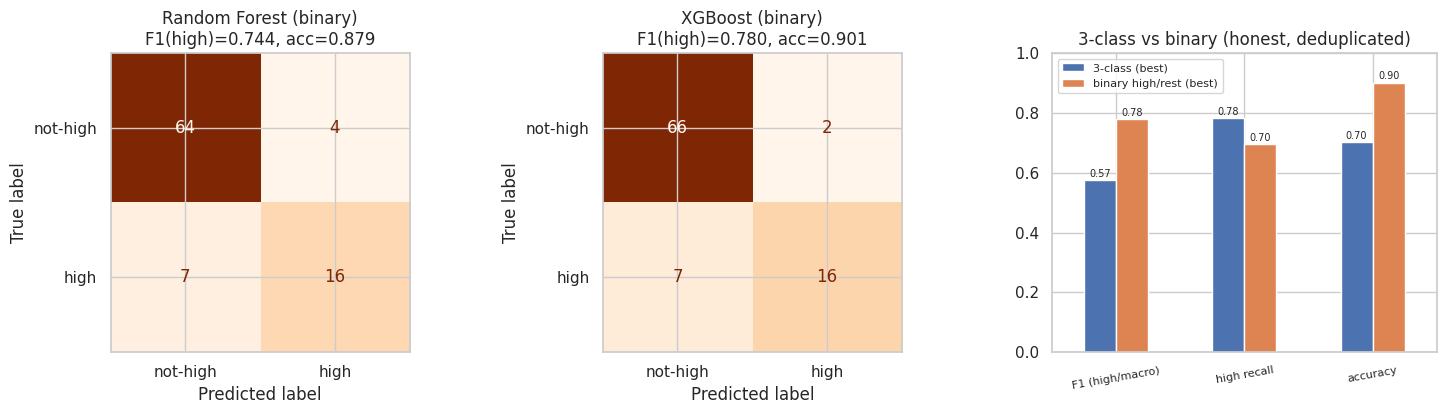

In [15]:
# Binary confusion matrices + a comparison of the headline numbers
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, name in zip(axes[:2], bin_models):
    cm = confusion_matrix(yb_te, bin_preds[name], labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["not-high", "high"]).plot(ax=ax, cmap="Oranges", colorbar=False)
    ax.set_title(f"{name} (binary)\nF1(high)={binary.loc[name,'test_F1_high']:.3f}, "
                 f"acc={binary.loc[name,'accuracy']:.3f}")

ax = axes[2]
comp = pd.DataFrame({
    "3-class (best)": [summary.iloc[0]["macroF1"], summary.iloc[0]["recall_high"], summary.iloc[0]["accuracy"]],
    "binary high/rest (best)": [binary["test_F1_high"].max(), binary["recall_high"].max(), binary["accuracy"].max()],
}, index=["F1 (high/macro)", "high recall", "accuracy"])
comp.plot.bar(ax=ax); ax.set_ylim(0, 1); ax.set_title("3-class vs binary (honest, deduplicated)")
ax.set_xticklabels(comp.index, rotation=10, fontsize=8); ax.legend(fontsize=8)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout(); plt.savefig(PLOTS / "14_binary_high_vs_rest.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Sensitivity analysis — the duplicate-leakage effect

Finally we repeat the 3-class evaluation on the **full split that still contains duplicates**.
Because identical rows sit in both train and test, the models memorise them and the metrics
**inflate**. This is the mechanism behind the high scores reported in prior work on this
dataset (e.g. Uddin & Karim, 2025: RF accuracy 0.891), which split *before* deduplicating.
The gap below is exactly why we deduplicated first.

In [16]:
Xf_tr, yf_tr, Xf_te, yf_te = load_xy("_full")
print("Full  train:", Xf_tr.shape, "test:", Xf_te.shape)
full_df, _, _ = fit_eval(make_models(), Xf_tr, yf_tr, Xf_te, yf_te, save=False)

compare = (test_df[["model", "macroF1", "accuracy", "recall_high"]]
           .merge(full_df[["model", "macroF1", "accuracy", "recall_high"]],
                  on="model", suffixes=("_dedup", "_full")))
compare["macroF1_inflation"] = (compare["macroF1_full"] - compare["macroF1_dedup"]).round(3)
compare = compare.round(3)
compare.to_csv("data/sensitivity_comparison.csv", index=False)
print("Duplicate leakage inflates metrics — full-split scores are NOT trustworthy:")
compare

Full  train: (809, 6) test: (203, 6)


Duplicate leakage inflates metrics — full-split scores are NOT trustworthy:


,model,macroF1_dedup,accuracy_dedup,recall_high_dedup,macroF1_full,accuracy_full,recall_high_full,macroF1_inflation
0,Decision Tree,0.575,0.703,0.783,0.652,0.675,0.800,0.077
1,Random Forest,0.619,0.681,0.696,0.778,0.768,0.909,0.159
2,XGBoost,0.571,0.593,0.696,0.859,0.852,0.909,0.288
3,Extra Trees,0.594,0.648,0.696,0.781,0.773,0.909,0.186
4,SVM,0.565,0.626,0.652,0.697,0.690,0.891,0.132
5,KNN,0.559,0.637,0.609,0.676,0.665,0.727,0.117
6,Naive Bayes,0.477,0.637,0.435,0.566,0.596,0.673,0.088


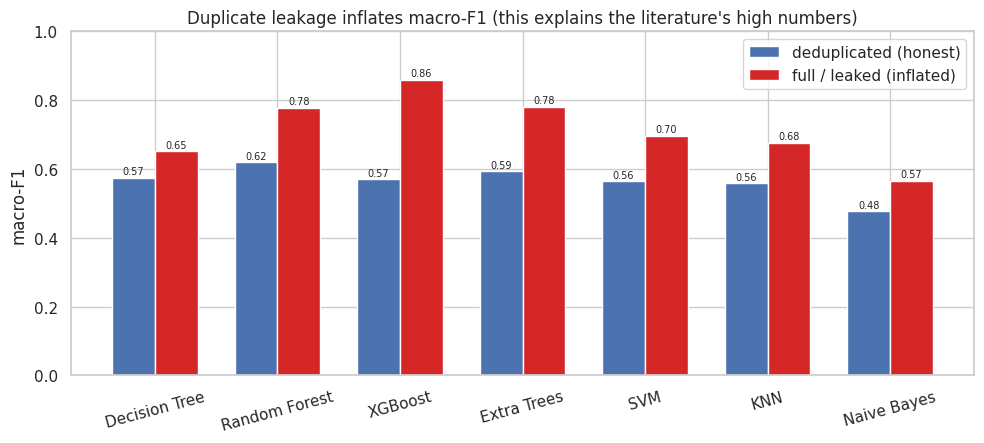

In [17]:
plt.figure(figsize=(10, 4.6))
x = np.arange(len(compare)); w = 0.35
plt.bar(x - w/2, compare["macroF1_dedup"], w, label="deduplicated (honest)", color="#4c72b0")
plt.bar(x + w/2, compare["macroF1_full"], w, label="full / leaked (inflated)", color="#d62728")
plt.xticks(x, compare["model"], rotation=15); plt.ylim(0, 1); plt.ylabel("macro-F1")
plt.title("Duplicate leakage inflates macro-F1 (this explains the literature's high numbers)")
for i, (d, f) in enumerate(zip(compare["macroF1_dedup"], compare["macroF1_full"])):
    plt.text(i - w/2, d + .01, f"{d:.2f}", ha="center", fontsize=7)
    plt.text(i + w/2, f + .01, f"{f:.2f}", ha="center", fontsize=7)
plt.legend(); plt.tight_layout()
plt.savefig(PLOTS / "15_sensitivity_leakage.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

- **Seven models** compared by 5-fold CV macro-F1 and a held-out test set. Random Forest is
  the strongest honest 3-class model (CV macro-F1 ≈ 0.62); SVM/XGBoost are close. The
  **mid-risk class** is the bottleneck — it overlaps low and high in vital-sign space.
- **GridSearchCV tuning** (Section 6) searches 216 configurations of `n_estimators`,
  `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`. Best params and
  test metrics are compared against the fixed-parameter baseline to confirm whether the 0.62
  ceiling is due to under-tuning or irreducible label noise.
- **Ablation:** SMOTE and engineered vitals (MAP, pulse pressure) do **not** beat the
  baseline. Combined with the conflicting-label audit (notebook 02) and the GridSearchCV
  result, this shows ~0.62 is a genuine *ceiling*, not under-tuning.
- **Binary high-vs-rest** is the clinically-decisive framing and is far stronger and honest:
  F1(high) ≈ 0.78, accuracy ≈ 0.90, high-recall ≈ 0.70 — comparable to published accuracy
  **without** the duplicate leakage those studies rely on.
- **Sensitivity analysis** reproduces that leakage: on the duplicate-containing split macro-F1
  jumps by up to ~0.29, explaining the 0.85–0.89 numbers reported elsewhere on this dataset.
- Fitted models (baseline + tuned RF) saved to `data/models/`; metrics to
  `data/{test_metrics, resampling_ablation, binary_high_vs_rest, sensitivity_comparison}.csv`
  for notebooks 05–06.

Next: **04_association_rules**.